## 4.2 Full Neural Network Model

This notebook builds the full neural network model using all input variables after Task 1 preprocessing and correlation-based feature removal. The ROC evaluation in this file is only for the full neural network model.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc


### Data preparation for neural network

Categorical variables are converted with one-hot encoding. Continuous numeric variables are standardised with `StandardScaler`, while binary dummy variables remain as 0/1 values. The scaler is fitted on the training data only and then applied to the test data.


In [12]:
df = pd.read_csv('../Asm1_dataset26.csv')
df.columns = df.columns.str.strip()
df = df.drop_duplicates(keep='first')

min_temp_cols = ['Min temp_D1_D30', 'Min temp_D31_D60', 'Min temp_D61_D90', 'Min temp_D91_D120']
for col in min_temp_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].replace('--', 'NA')

df['yield_per_hec'] = df['Paddy yield(in Kg)'] / df['Hectares']
mean_yield = df['yield_per_hec'].mean()
df['isAboveAvg'] = np.where(df['yield_per_hec'] > mean_yield, 1, 0)

drop_cols = ['Hectares', 'Paddy yield(in Kg)', 'yield_per_hec', 'Trash(in bundles)']
df_clean = df.drop(columns=drop_cols)

df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
X = df_encoded.drop(columns=['isAboveAvg'])
y = df_encoded['isAboveAvg']

corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.98)]
X_final = X.drop(columns=high_corr_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2]
continuous_cols = [col for col in X_train.columns if col not in binary_cols]

scaler = StandardScaler()
X_train_nn = X_train.copy()
X_test_nn = X_test.copy()

X_train_nn[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_nn[continuous_cols] = scaler.transform(X_test[continuous_cols])

X_train_nn = X_train_nn.astype(float)
X_test_nn = X_test_nn.astype(float)

print(f'Full feature matrix: {X_final.shape}')
print(f'Train size: {X_train_nn.shape}')
print(f'Test size: {X_test_nn.shape}')
print(f'Number of continuous variables scaled: {len(continuous_cols)}')
print(f'Number of binary variables kept as 0/1: {len(binary_cols)}')


Full feature matrix: (2628, 50)
Train size: (1971, 50)
Test size: (657, 50)
Number of continuous variables scaled: 19
Number of binary variables kept as 0/1: 31


### GridSearchCV for full neural network

The full model uses all 50 input variables. The search tests small and medium hidden-layer structures, two activation functions, different L2 regularisation strengths, and two initial learning rates.


In [ ]:
random_state = 10
nn = MLPClassifier(
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=random_state
)

param_grid_nn = {
    'hidden_layer_sizes': [(25,), (50,), (50, 25),(100,), (100, 50), (50, 25, 10)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.01]
}

grid_search_nn = GridSearchCV(
    estimator=nn,
    param_grid=param_grid_nn,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_nn.fit(X_train_nn, y_train)

best_nn = grid_search_nn.best_estimator_
y_train_pred_nn = best_nn.predict(X_train_nn)
y_test_pred_nn = best_nn.predict(X_test_nn)

train_acc_nn = accuracy_score(y_train, y_train_pred_nn)
test_acc_nn = accuracy_score(y_test, y_test_pred_nn)
accuracy_gap_nn = train_acc_nn - test_acc_nn
converged_nn = best_nn.n_iter_ < best_nn.max_iter

print('Best full neural network parameters:')
print(grid_search_nn.best_params_)
print(f'Best cross-validation accuracy: {grid_search_nn.best_score_:.4f}')
print(f'Train accuracy: {train_acc_nn:.4f}')
print(f'Test accuracy: {test_acc_nn:.4f}')
print(f'Train-test accuracy gap: {accuracy_gap_nn:.4f}')
print(f'Iterations used by best model: {best_nn.n_iter_}')
print(f'Did the training stop before max_iter? {converged_nn}')
print(f'Final loss: {best_nn.loss_:.4f}')


Best full neural network parameters:
{'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01}
Best cross-validation accuracy: 0.8899
Train accuracy: 0.9224
Test accuracy: 0.8828
Train-test accuracy gap: 0.0396
Iterations used by best model: 69
Did the training stop before max_iter? True
Final loss: 0.1708


In [14]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred_nn))

              precision    recall  f1-score   support

           0       0.91      0.85      0.88       332
           1       0.86      0.92      0.89       325

    accuracy                           0.88       657
   macro avg       0.88      0.88      0.88       657
weighted avg       0.88      0.88      0.88       657



In [15]:
nn_cv_results = pd.DataFrame(grid_search_nn.cv_results_).sort_values('rank_test_score')
nn_cv_results[[
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'param_hidden_layer_sizes',
    'param_activation',
    'param_alpha',
    'param_learning_rate_init'
]].head(10)


,rank_test_score,mean_test_score,std_test_score,param_hidden_layer_sizes,param_activation,param_alpha,param_learning_rate_init
29,1,0.889902,0.019413,"(50, 25)",tanh,0.0010,0.010
23,1,0.889902,0.019413,"(50, 25)",tanh,0.0001,0.010
35,3,0.889394,0.018978,"(50, 25)",tanh,0.0100,0.010
17,4,0.888381,0.021175,"(50, 25)",relu,0.0100,0.010
7,5,0.887871,0.020877,"(25,)",relu,0.0010,0.010
5,6,0.887371,0.019341,"(50, 25)",relu,0.0001,0.010
1,7,0.887363,0.019387,"(25,)",relu,0.0001,0.010
11,8,0.885838,0.017804,"(50, 25)",relu,0.0010,0.010
10,9,0.885333,0.024594,"(50, 25)",relu,0.0010,0.001
13,10,0.885330,0.019191,"(25,)",relu,0.0100,0.010


In [16]:
nn_cv_results = pd.DataFrame(grid_search_nn.cv_results_).sort_values('rank_test_score')
nn_cv_results.iloc[:8]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_activation,param_alpha,param_hidden_layer_sizes,param_learning_rate_init,params,split0_test_score,...,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
29,1.437894,0.466761,0.011237,0.004568,tanh,0.0010,"(50, 25)",0.01,"{'activation': 'tanh', 'alpha': 0.001, 'hidden...",0.893939,...,0.862944,0.888325,0.898477,0.898477,0.903553,0.857868,0.908629,0.889902,0.019413,1
23,1.322119,0.422667,0.015648,0.006838,tanh,0.0001,"(50, 25)",0.01,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",0.893939,...,0.862944,0.888325,0.898477,0.898477,0.903553,0.857868,0.908629,0.889902,0.019413,1
35,1.225945,0.376697,0.010797,0.005714,tanh,0.0100,"(50, 25)",0.01,"{'activation': 'tanh', 'alpha': 0.01, 'hidden_...",0.893939,...,0.862944,0.888325,0.898477,0.898477,0.903553,0.857868,0.903553,0.889394,0.018978,3
17,0.861300,0.167169,0.010347,0.003912,relu,0.0100,"(50, 25)",0.01,"{'activation': 'relu', 'alpha': 0.01, 'hidden_...",0.888889,...,0.847716,0.893401,0.898477,0.898477,0.913706,0.857868,0.888325,0.888381,0.021175,4
7,1.024333,0.385455,0.011164,0.005640,relu,0.0010,"(25,)",0.01,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",0.893939,...,0.852792,0.878173,0.883249,0.898477,0.913706,0.868020,0.898477,0.887871,0.020877,5
5,1.095868,0.342269,0.016295,0.017157,relu,0.0001,"(50, 25)",0.01,"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",0.878788,...,0.842640,0.888325,0.903553,0.898477,0.898477,0.888325,0.878173,0.887371,0.019341,6
1,0.662658,0.224019,0.012013,0.012880,relu,0.0001,"(25,)",0.01,"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",0.893939,...,0.852792,0.883249,0.873096,0.898477,0.903553,0.878173,0.898477,0.887363,0.019387,7
11,1.154930,0.469739,0.012028,0.006043,relu,0.0010,"(50, 25)",0.01,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",0.898990,...,0.857868,0.888325,0.883249,0.898477,0.903553,0.857868,0.883249,0.885838,0.017804,8


### ROC evaluation for full neural network

This ROC curve evaluates only the full neural network model. The final combined comparison will be written later.


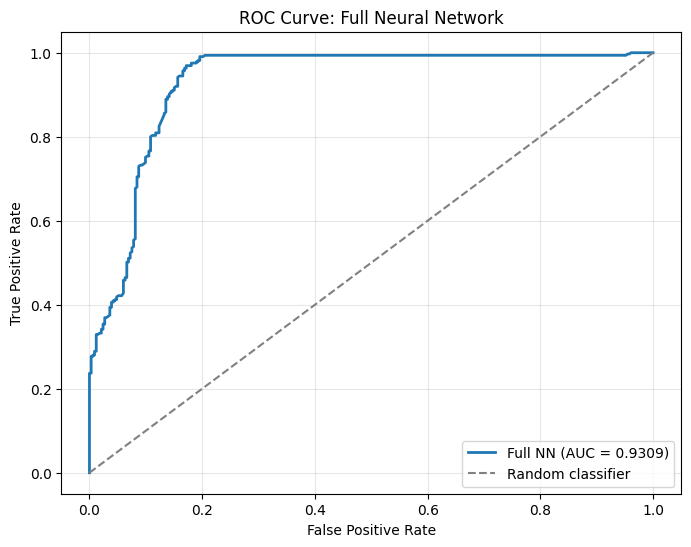

Full neural network AUC: 0.9309


In [17]:
y_prob_nn = best_nn.predict_proba(X_test_nn)[:, 1]
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nn, tpr_nn, label=f'Full NN (AUC = {auc_nn:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Full Neural Network')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f'Full neural network AUC: {auc_nn:.4f}')
